# Hybrid Modeling Strategies

## Datasets and Setup with Polars

### Dataset Choice

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path().resolve().parent))
from config import DATA_RAW, DATA_PROCESSED, FIGURES, RANDOM_SEED

sns.set_theme(style="whitegrid", palette="muted")
rng = np.random.default_rng(RANDOM_SEED)

# ══════════════════════════════════════════════════════════════════════════
# Setup
# ══════════════════════════════════════════════════════════════════════════
BASE_URL = "https://d37ci6vzurychx.cloudfront.net/trip-data"
MONTHS = [f"yellow_tripdata_2023-{m:02d}.parquet" for m in range(1, 7)]

sns.set_theme(style="whitegrid", palette="muted")

# ══════════════════════════════════════════════════════════════════════════
# Lazy load + schema normalization
# ══════════════════════════════════════════════════════════════════════════
frames = []

for m in MONTHS:
    url = f"{BASE_URL}/{m}"

    lf = (
        pl.scan_parquet(url)
        .select([
            "tpep_pickup_datetime",
            pl.col("PULocationID").cast(pl.Int64),
            pl.col("passenger_count").cast(pl.Float64),
            pl.col("trip_distance").cast(pl.Float64),
            pl.col("fare_amount").cast(pl.Float64),
        ])
        .filter(
            (pl.col("fare_amount") > 0) &
            (pl.col("trip_distance") > 0) &
            (pl.col("passenger_count") > 0)
        )
    )

    frames.append(lf)

# Safe concatenation (schema aligned)
lf_all = pl.concat(frames)

# ══════════════════════════════════════════════════════════════════════════
# Feature engineering + aggregation (lazy)
# ══════════════════════════════════════════════════════════════════════════
hourly_lf = (
    lf_all
    .with_columns(
        pl.col("tpep_pickup_datetime")
        .dt.truncate("1h")
        .alias("hour")
    )
    .group_by("hour")
    .agg([
        pl.len().alias("trip_count"),
        pl.col("fare_amount").mean().alias("avg_fare"),
        pl.col("trip_distance").mean().alias("avg_distance"),
        pl.col("passenger_count").mean().alias("avg_passengers"),
    ])
    .sort("hour")
)

# ══════════════════════════════════════════════════════════════════════════
# Materialize once (single execution)
# ══════════════════════════════════════════════════════════════════════════
df_hourly = hourly_lf.collect()

# ══════════════════════════════════════════════════════════════════════════
# Output diagnostics
# ══════════════════════════════════════════════════════════════════════════
print(f"Polars version  : {pl.__version__}")
print(f"Total rows      : {lf_all.select(pl.len()).collect()[0,0]:,}")
print(f"Hourly buckets  : {df_hourly.shape[0]:,}")

print(
    f"Date range      : "
    f"{df_hourly['hour'].min()} → {df_hourly['hour'].max()}"
)

print("\nSchema:")
print(df_hourly.schema)

print("\nFirst 5 rows:")
print(df_hourly.head(5))

Polars version  : 1.40.0
Total rows      : 18,251,728
Hourly buckets  : 4,372
Date range      : 2001-01-01 00:00:00 → 2023-09-05 18:00:00

Schema:
Schema({'hour': Datetime(time_unit='ns', time_zone=None), 'trip_count': UInt32, 'avg_fare': Float64, 'avg_distance': Float64, 'avg_passengers': Float64})

First 5 rows:
shape: (5, 5)
┌─────────────────────┬────────────┬───────────┬──────────────┬────────────────┐
│ hour                ┆ trip_count ┆ avg_fare  ┆ avg_distance ┆ avg_passengers │
│ ---                 ┆ ---        ┆ ---       ┆ ---          ┆ ---            │
│ datetime[ns]        ┆ u32        ┆ f64       ┆ f64          ┆ f64            │
╞═════════════════════╪════════════╪═══════════╪══════════════╪════════════════╡
│ 2001-01-01 00:00:00 ┆ 5          ┆ 47.02     ┆ 11.126       ┆ 1.2            │
│ 2001-01-01 15:00:00 ┆ 1          ┆ 38.0      ┆ 9.13         ┆ 2.0            │
│ 2002-12-31 23:00:00 ┆ 6          ┆ 43.766667 ┆ 10.395       ┆ 1.0            │
│ 2003-01-01 00:00:00 

### Preprocessing and Target Creation

Total hourly observations : 4,372
Training period : 2001-01-01 – 2023-06-01 (3,652 obs)
Test period     : 2023-06-01 – 2023-09-05 (720 obs)
High-demand threshold : 6272 trips/hour (20.0% positive rate)


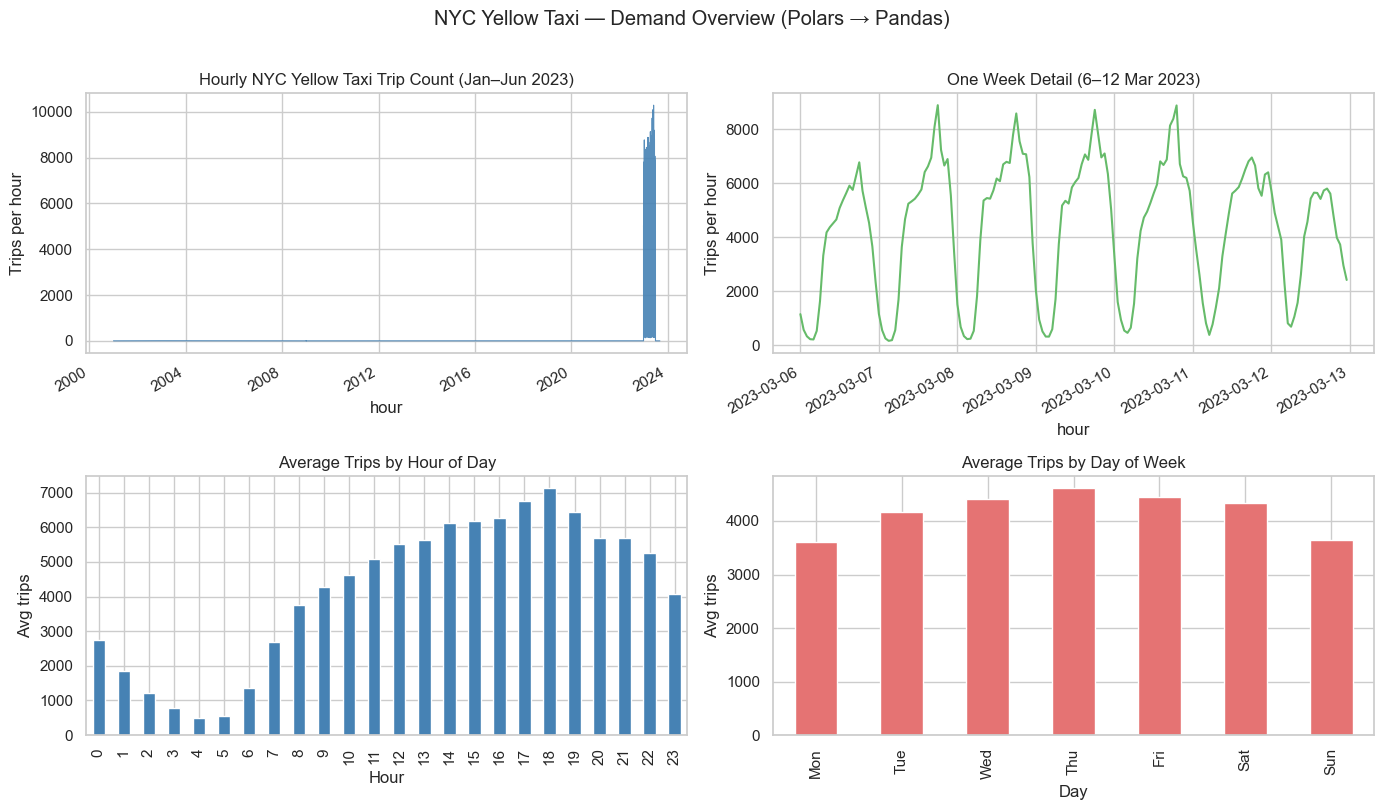

In [2]:
# ── Convert to pandas for downstream statsmodels/sklearn/PyTorch compatibility ──
df = df_hourly.to_pandas()
df["hour"] = pd.to_datetime(df["hour"])
df = df.set_index("hour").sort_index()

# Remove sparse boundary hours (likely incomplete data)
df = df.between_time("00:00", "23:00")

# ── Calendar features ──────────────────────────────────────────────────────
df["hour_of_day"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"]       = df.index.month
df["is_weekend"]  = (df.index.dayofweek >= 5).astype(int)
df["hour_sin"]    = np.sin(2 * np.pi * df["hour_of_day"] / 24)
df["hour_cos"]    = np.cos(2 * np.pi * df["hour_of_day"] / 24)
df["dow_sin"]     = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"]     = np.cos(2 * np.pi * df["day_of_week"] / 7)

# ── Binary classification target: top quintile = "high demand" ────────────
threshold = df["trip_count"].quantile(0.80)
df["high_demand"] = (df["trip_count"] >= threshold).astype(int)

# ── Train / test split (last 30 days = test) ──────────────────────────────
HOLDOUT_HOURS = 24 * 30
train_df = df.iloc[:-HOLDOUT_HOURS]
test_df  = df.iloc[-HOLDOUT_HOURS:]

print(f"Total hourly observations : {len(df):,}")
print(f"Training period : {train_df.index[0].date()} – {train_df.index[-1].date()} "
      f"({len(train_df):,} obs)")
print(f"Test period     : {test_df.index[0].date()} – {test_df.index[-1].date()} "
      f"({len(test_df):,} obs)")
print(f"High-demand threshold : {threshold:.0f} trips/hour "
      f"({df['high_demand'].mean()*100:.1f}% positive rate)")

# ── Overview plot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

df["trip_count"].plot(ax=axes[0, 0], color="steelblue", lw=0.8, alpha=0.9)
axes[0, 0].set_title("Hourly NYC Yellow Taxi Trip Count (Jan–Jun 2023)")
axes[0, 0].set_ylabel("Trips per hour")

# One representative week
week = df["trip_count"]["2023-03-06":"2023-03-12"]
week.plot(ax=axes[0, 1], color="#66BB6A", lw=1.5)
axes[0, 1].set_title("One Week Detail (6–12 Mar 2023)")
axes[0, 1].set_ylabel("Trips per hour")

# Average by hour of day
hourly_avg = df.groupby("hour_of_day")["trip_count"].mean()
hourly_avg.plot(kind="bar", ax=axes[1, 0], color="steelblue", edgecolor="white")
axes[1, 0].set_title("Average Trips by Hour of Day")
axes[1, 0].set_xlabel("Hour"); axes[1, 0].set_ylabel("Avg trips")

# Average by day of week
dow_avg = df.groupby("day_of_week")["trip_count"].mean()
dow_avg.index = ["Mon","Tue","Wed","Thu","Fri","Sat","Sun"]
dow_avg.plot(kind="bar", ax=axes[1, 1], color="#E57373", edgecolor="white")
axes[1, 1].set_title("Average Trips by Day of Week")
axes[1, 1].set_xlabel("Day"); axes[1, 1].set_ylabel("Avg trips")

plt.suptitle("NYC Yellow Taxi — Demand Overview (Polars → Pandas)", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch10_data_overview.png", dpi=150, bbox_inches="tight")
plt.show()

## Statistical–ML Hybrid: Decomposition and Residual Learning

### Motivation and Architecture

In [3]:
from statsmodels.tsa.seasonal import STL
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import lightgbm as lgb

TARGET = "trip_count"
y_train = train_df[TARGET]
y_test  = test_df[TARGET]

# ── Step 1: STL decomposition on training series ───────────────────────────
# period=24 captures daily seasonality; robust=True handles demand spikes
stl = STL(y_train, period=24, robust=True)
stl_result = stl.fit()

trend_train    = stl_result.trend
seasonal_train = stl_result.seasonal
resid_train    = stl_result.resid

print("STL decomposition — training series:")
print(f"  Trend    variance explained : "
      f"{np.var(trend_train)/np.var(y_train)*100:.1f}%")
print(f"  Seasonal variance explained : "
      f"{np.var(seasonal_train)/np.var(y_train)*100:.1f}%")
print(f"  Residual variance           : "
      f"{np.var(resid_train)/np.var(y_train)*100:.1f}% of total")

# ── Step 2: Feature engineering on the residual ────────────────────────────
def make_resid_features(series_index, resid_values, original_df):
    """Build lag + rolling + calendar features for residual learning."""
    feat = pd.DataFrame(index=series_index)
    resid_s = pd.Series(resid_values, index=series_index)

    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:   # 168 = 1 week
        feat[f"resid_lag_{lag}"] = resid_s.shift(lag)
    for w in [6, 12, 24]:
        feat[f"resid_roll_mean_{w}"] = resid_s.shift(1).rolling(w).mean()
        feat[f"resid_roll_std_{w}"]  = resid_s.shift(1).rolling(w).std()

    # Calendar features from the original dataframe
    for col in ["hour_sin", "hour_cos", "dow_sin", "dow_cos",
                "is_weekend", "month"]:
        feat[col] = original_df.loc[series_index, col]

    return feat.dropna()

feat_train = make_resid_features(
    y_train.index, resid_train.values, train_df
)
resid_target = resid_train.loc[feat_train.index]

print(f"\nResidual feature matrix : {feat_train.shape}")
print(f"Residual target range   : [{resid_target.min():.0f}, {resid_target.max():.0f}]")

# ── Step 3: Train gradient boosting on the residual ───────────────────────
tscv = TimeSeriesSplit(n_splits=5, test_size=24 * 7)

lgb_resid = lgb.LGBMRegressor(
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    n_jobs=-1,
    verbose=-1
)

cv_maes = []
for tr_idx, val_idx in tscv.split(feat_train):
    lgb_resid.fit(feat_train.iloc[tr_idx], resid_target.iloc[tr_idx])
    pred = lgb_resid.predict(feat_train.iloc[val_idx])
    cv_maes.append(mean_absolute_error(resid_target.iloc[val_idx], pred))

print(f"\nLightGBM residual CV MAE : {np.mean(cv_maes):.1f} ± {np.std(cv_maes):.1f} trips")

lgb_resid.fit(feat_train, resid_target)

STL decomposition — training series:
  Trend    variance explained : 6.3%
  Seasonal variance explained : 97.5%
  Residual variance           : 12.3% of total

Residual feature matrix : (3484, 20)
Residual target range   : [-3355, 4430]

LightGBM residual CV MAE : 178.5 ± 33.5 trips


,boosting_type,'gbdt'
,num_leaves,63
,max_depth,-1
,learning_rate,0.05
,n_estimators,400
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [4]:
# ── Step 4: STL forecast for the test horizon ─────────────────────────────
HORIZON = len(y_test)
from sklearn.linear_model import LinearRegression

trend_vals  = trend_train.values
t_idx       = np.arange(len(trend_vals))
lr_trend    = LinearRegression().fit(t_idx[-168:].reshape(-1, 1),
                                      trend_vals[-168:])
t_future    = np.arange(len(trend_vals), len(trend_vals) + HORIZON)
trend_fc    = lr_trend.predict(t_future.reshape(-1, 1))

# Seasonal: tile the last complete day-of-week × hour-of-day cycle (168 h)
season_cycle  = seasonal_train.values[-168:]
reps          = int(np.ceil(HORIZON / 168))
seasonal_fc   = np.tile(season_cycle, reps)[:HORIZON]

# ── Step 5: Predict residuals for the test period ─────────────────────────
full_resid = pd.concat([
    resid_train,
    pd.Series(np.zeros(HORIZON), index=y_test.index)
])

feat_test_list = []
for i in range(HORIZON):
    row_idx = y_test.index[i]
    row = {}
    for lag in [1, 2, 3, 6, 12, 24, 48, 168]:
        lookback_idx = i + len(resid_train) - lag
        row[f"resid_lag_{lag}"] = (full_resid.iloc[lookback_idx]
                                   if lookback_idx >= 0 else 0)
    for w in [6, 12, 24]:
        lb = max(0, i + len(resid_train) - w)
        row[f"resid_roll_mean_{w}"] = full_resid.iloc[lb: i + len(resid_train)].mean()
        row[f"resid_roll_std_{w}"]  = full_resid.iloc[lb: i + len(resid_train)].std()
    for col in ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend", "month"]:
        row[col] = test_df.loc[row_idx, col]
    feat_test_list.append(row)

feat_test = pd.DataFrame(feat_test_list, index=y_test.index)
resid_fc  = lgb_resid.predict(feat_test)

# ── Step 6: Combine components ────────────────────────────────────────────
hybrid_fc = trend_fc + seasonal_fc + resid_fc

# ── Baselines ─────────────────────────────────────────────────────────────
stl_only_fc = trend_fc + seasonal_fc

naive_fc = np.tile(y_train.values[-168:],
                   int(np.ceil(HORIZON / 168)))[:HORIZON]

feat_raw_tr = make_resid_features(y_train.index, y_train.values, train_df)
lgb_raw = lgb.LGBMRegressor(
    n_estimators=400, learning_rate=0.05, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8,
    random_state=RANDOM_SEED, n_jobs=-1, verbose=-1
)
lgb_raw.fit(feat_raw_tr, y_train.loc[feat_raw_tr.index])

full_index  = y_train.index.append(y_test.index)
full_values = np.concatenate([y_train.values, np.zeros(HORIZON)])
feat_full   = make_resid_features(full_index, full_values, df)
feat_raw_te = feat_full.loc[y_test.index]
lgb_raw_fc  = lgb_raw.predict(feat_raw_te)

def forecast_metrics(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"  {label:<40}  MAE={mae:>7.0f}  RMSE={rmse:>7.0f}  MAPE={mape:>5.2f}%")
    return mae, rmse, mape

print("\nTest set forecast accuracy (30-day horizon, hourly):")
print(f"  {'Model':<40}  {'MAE':>8}  {'RMSE':>8}  {'MAPE':>7}")
print("  " + "─" * 65)
results_decomp = {}
for name, fc in [
    ("Seasonal naïve",          naive_fc),
    ("STL only (no ML)",        stl_only_fc),
    ("LightGBM only (raw lags)", lgb_raw_fc),
    ("STL + LightGBM (hybrid)", hybrid_fc),
]:
    m = forecast_metrics(y_test.values, fc, name)
    results_decomp[name] = m


Test set forecast accuracy (30-day horizon, hourly):
  Model                                          MAE      RMSE     MAPE
  ─────────────────────────────────────────────────────────────────
  Seasonal naïve                            MAE=    607  RMSE=    853  MAPE=4872984961.69%
  STL only (no ML)                          MAE=    782  RMSE=   1013  MAPE=2058.25%
  LightGBM only (raw lags)                  MAE=   2833  RMSE=   3308  MAPE=1740.40%
  STL + LightGBM (hybrid)                   MAE=    721  RMSE=    914  MAPE=2342.31%


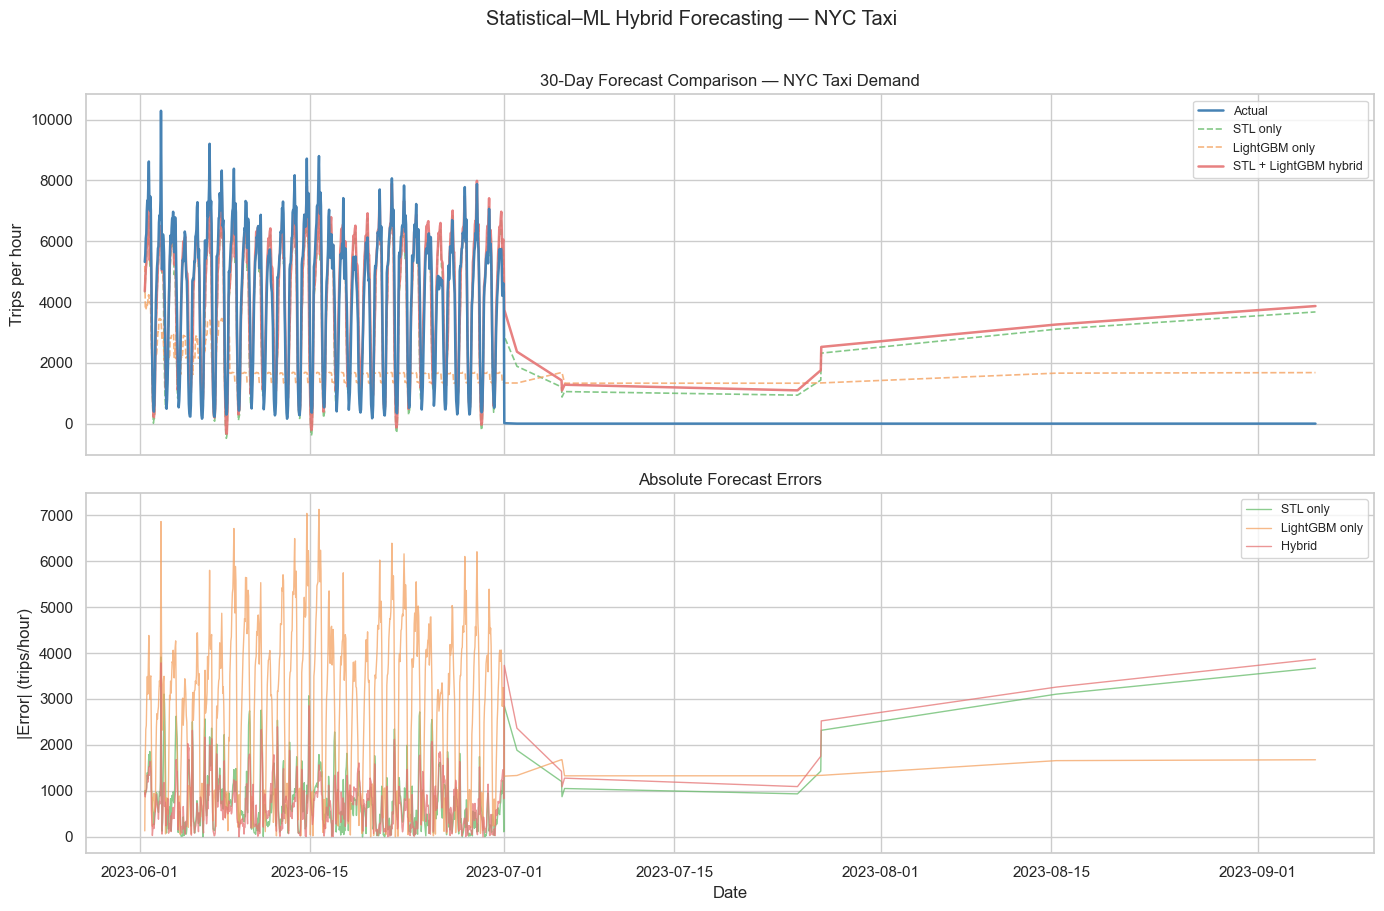

In [5]:
# ── Visual comparison: actual vs. forecasts ────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

x_axis = y_test.index
axes[0].plot(x_axis, y_test.values,    color="steelblue", lw=1.8,
             label="Actual", zorder=5)
axes[0].plot(x_axis, stl_only_fc,      color="#66BB6A",   lw=1.2,
             alpha=0.8, linestyle="--", label="STL only")
axes[0].plot(x_axis, lgb_raw_fc,       color="#F4A261",   lw=1.2,
             alpha=0.8, linestyle="--", label="LightGBM only")
axes[0].plot(x_axis, hybrid_fc,        color="#E57373",   lw=1.8,
             alpha=0.9, label="STL + LightGBM hybrid")
axes[0].set_ylabel("Trips per hour")
axes[0].set_title("30-Day Forecast Comparison — NYC Taxi Demand")
axes[0].legend(fontsize=9)

for fc, color, label in [
    (stl_only_fc, "#66BB6A",  "STL only"),
    (lgb_raw_fc,  "#F4A261",  "LightGBM only"),
    (hybrid_fc,   "#E57373",  "Hybrid"),
]:
    axes[1].plot(x_axis, np.abs(y_test.values - fc),
                 color=color, lw=1, alpha=0.75, label=label)
axes[1].set_ylabel("|Error| (trips/hour)")
axes[1].set_xlabel("Date")
axes[1].set_title("Absolute Forecast Errors")
axes[1].legend(fontsize=9)

plt.suptitle("Statistical–ML Hybrid Forecasting — NYC Taxi", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES / "ch10_hybrid_decomp.png", dpi=150, bbox_inches="tight")
plt.show()

## Stacking Ensembles: Combining Heterogeneous Models

### The Stacking Framework

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    f1_score, classification_report
)

# ── Classification target: high demand hour (top quintile) ─────────────────
FEAT_COLS = ["hour_sin", "hour_cos", "dow_sin", "dow_cos",
             "is_weekend", "month", "avg_fare", "avg_distance"]

X_tr_cls = train_df[FEAT_COLS].values
y_tr_cls = train_df["high_demand"].values
X_te_cls = test_df[FEAT_COLS].values
y_te_cls = test_df["high_demand"].values

scaler_cls = StandardScaler()
X_tr_sc = scaler_cls.fit_transform(X_tr_cls)
X_te_sc = scaler_cls.transform(X_te_cls)

print(f"Classification task — high demand prediction")
print(f"  Train: {len(y_tr_cls):,} obs, {y_tr_cls.sum():,} positive "
      f"({y_tr_cls.mean()*100:.1f}%)")
print(f"  Test : {len(y_te_cls):,} obs, {y_te_cls.sum():,} positive "
      f"({y_te_cls.mean()*100:.1f}%)")

# ── Define base learners ───────────────────────────────────────────────────
base_learners = {
    "Logistic Regression":   LogisticRegression(C=1.0, max_iter=1000,
                                                random_state=RANDOM_SEED),
    "Random Forest":         RandomForestClassifier(n_estimators=300,
                                                    max_depth=8,
                                                    random_state=RANDOM_SEED,
                                                    n_jobs=-1),
    "LightGBM":              lgb.LGBMClassifier(n_estimators=300,
                                                learning_rate=0.05,
                                                num_leaves=31,
                                                random_state=RANDOM_SEED,
                                                n_jobs=-1, verbose=-1),
    "KNN (k=15)":            KNeighborsClassifier(n_neighbors=15, n_jobs=-1),
}

# ── Out-of-fold (OOF) prediction loop ─────────────────────────────────────
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

oof_preds  = np.zeros((len(y_tr_cls), len(base_learners)))
test_preds = np.zeros((len(y_te_cls), len(base_learners)))

print("\nGenerating OOF predictions:")
for m_idx, (name, model) in enumerate(base_learners.items()):
    fold_test_preds = np.zeros((N_FOLDS, len(y_te_cls)))
    fold_oof_auc    = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X_tr_sc, y_tr_cls)):
        model.fit(X_tr_sc[tr_idx], y_tr_cls[tr_idx])
        val_prob = model.predict_proba(X_tr_sc[val_idx])[:, 1]
        oof_preds[val_idx, m_idx] = val_prob
        fold_oof_auc.append(roc_auc_score(y_tr_cls[val_idx], val_prob))
        fold_test_preds[fold] = model.predict_proba(X_te_sc)[:, 1]

    test_preds[:, m_idx] = fold_test_preds.mean(axis=0)
    print(f"  {name:<25} OOF ROC-AUC: {np.mean(fold_oof_auc):.4f} "
          f"± {np.std(fold_oof_auc):.4f}")

print(f"\nOOF prediction matrix shape : {oof_preds.shape}")
print(f"Test prediction matrix shape : {test_preds.shape}")

Classification task — high demand prediction
  Train: 3,652 obs, 730 positive (20.0%)
  Test : 720 obs, 145 positive (20.1%)

Generating OOF predictions:
  Logistic Regression       OOF ROC-AUC: 0.9677 ± 0.0056
  Random Forest             OOF ROC-AUC: 0.9745 ± 0.0054
  LightGBM                  OOF ROC-AUC: 0.9732 ± 0.0058
  KNN (k=15)                OOF ROC-AUC: 0.9707 ± 0.0055

OOF prediction matrix shape : (3652, 4)
Test prediction matrix shape : (720, 4)


In [7]:
# ── Train meta-learner on OOF predictions ─────────────────────────────────
meta_lr = LogisticRegression(C=0.5, max_iter=1000, random_state=RANDOM_SEED)
meta_lr.fit(oof_preds, y_tr_cls)

stack_prob = meta_lr.predict_proba(test_preds)[:, 1]
stack_pred = (stack_prob >= 0.5).astype(int)

print("\nTest set results — Stacking vs. base models:")
print(f"  {'Model':<28}  {'ROC-AUC':>8}  {'PR-AUC':>8}  {'F1':>7}")
print("  " + "─" * 57)

individual_results = {}
for m_idx, (name, model) in enumerate(base_learners.items()):
    model.fit(X_tr_sc, y_tr_cls)
    te_prob = model.predict_proba(X_te_sc)[:, 1]
    te_pred = (te_prob >= 0.5).astype(int)
    roc = roc_auc_score(y_te_cls, te_prob)
    apr = average_precision_score(y_te_cls, te_prob)
    f1  = f1_score(y_te_cls, te_pred)
    individual_results[name] = (roc, apr, f1, te_prob)
    print(f"  {name:<28}  {roc:>8.4f}  {apr:>8.4f}  {f1:>7.4f}")

roc_stack = roc_auc_score(y_te_cls, stack_prob)
apr_stack = average_precision_score(y_te_cls, stack_prob)
f1_stack  = f1_score(y_te_cls, stack_pred)
print(f"  {'Stacking Ensemble':<28}  {roc_stack:>8.4f}  {apr_stack:>8.4f}  {f1_stack:>7.4f}")

print(f"\nMeta-learner coefficients (base model weights):")
for name, coef in zip(base_learners.keys(), meta_lr.coef_[0]):
    print(f"  {name:<28} : {coef:>+.4f}")


Test set results — Stacking vs. base models:
  Model                          ROC-AUC    PR-AUC       F1
  ─────────────────────────────────────────────────────────
  Logistic Regression             0.9345    0.7160   0.7268
  Random Forest                   0.9584    0.8064   0.7668
  LightGBM                        0.9594    0.8045   0.8000
  KNN (k=15)                      0.9357    0.7317   0.7407
  Stacking Ensemble               0.9543    0.8073   0.7610

Meta-learner coefficients (base model weights):
  Logistic Regression          : +1.4684
  Random Forest                : +2.8294
  LightGBM                     : +1.1949
  KNN (k=15)                   : +2.5084


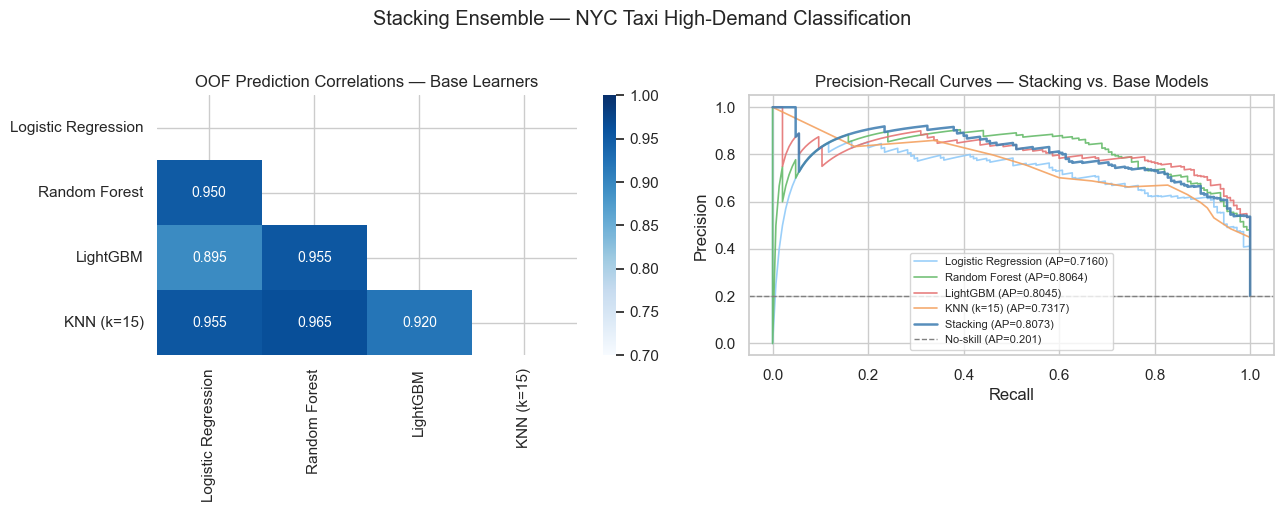

In [8]:
# ── Visualise: OOF prediction correlations and PR curves ──────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

corr_df = pd.DataFrame(oof_preds, columns=list(base_learners.keys()))
mask    = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), annot=True, fmt=".3f", cmap="Blues",
            ax=axes[0], mask=mask, vmin=0.7, vmax=1.0,
            annot_kws={"size": 10})
axes[0].set_title("OOF Prediction Correlations — Base Learners")

from sklearn.metrics import precision_recall_curve
colors = ["#90CAF9", "#66BB6A", "#E57373", "#F4A261", "steelblue"]
for (name, (roc, apr, f1, te_prob)), color in zip(
        list(individual_results.items()) + [("Stacking", (roc_stack, apr_stack, f1_stack, stack_prob))],
        colors):
    prec, rec, _ = precision_recall_curve(y_te_cls, te_prob)
    axes[1].plot(rec, prec, lw=1.8 if name == "Stacking" else 1.2,
                 color=color, alpha=0.9,
                 label=f"{name} (AP={apr:.4f})")
axes[1].axhline(y_te_cls.mean(), color="gray", lw=1, linestyle="--",
                label=f"No-skill (AP={y_te_cls.mean():.3f})")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves — Stacking vs. Base Models")
axes[1].legend(fontsize=8)

plt.suptitle("Stacking Ensemble — NYC Taxi High-Demand Classification", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "ch10_stacking.png", dpi=150, bbox_inches="tight")
plt.show()